In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt

import torch
from torchvision import transforms

from data import DicomDataset
from brain_transforms import get_spatial_transform_list

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
from model import DiagnosticModel

In [4]:
data_dir = Path('/data/vision/polina/users/marcusbl/data')
model_path = Path('/data/vision/polina/users/marcusbl/bin_class/outputs6/relabel/run0/best_model.pth')
dataset = DicomDataset(data_dir)

Loading People Data: 100%|██████████| 30/30 [00:00<00:00, 56.21it/s]


In [5]:
model = DiagnosticModel(model_name = 'resnet50', include_weights = False, in_channels = 3)
checkpoint = torch.load(model_path, map_location=next(model.parameters()).device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
""

''

In [6]:
aug_list = get_spatial_transform_list(trans_perc = 0.4)
dataset.set_norm(norm_method = "min-max", mask_method="stack", masked_norm=True, perc_norm=0)
dataset.set_aug(aug_list)
# dataset.set_aug(None)

In [7]:
idx = 271

Probability of Clean Slice: 0.9876611232757568


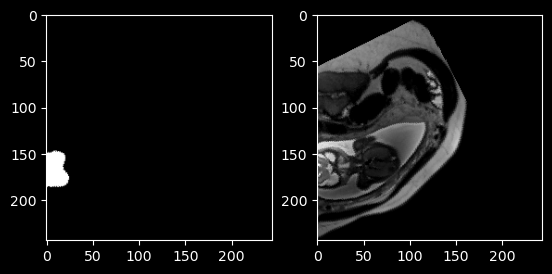

In [ ]:
full = dataset[idx][0]

mask = full[1]
scan = full[0]

fig, ax = plt.subplots(ncols = 2)
ax[0].imshow(mask, vmin=0, vmax=1, cmap='grey')
ax[1].imshow(scan, cmap="gray")
# ax[1].imshow(mask, vmin=0, vmax = 1, alpha=0.4, cmap="Reds")

model_input = scan.repeat(3, 1, 1).unsqueeze(0)
model_output = model(model_input).squeeze()
prob_clean = torch.functional.F.softmax(model_output, dim = 0)[0]

print(f"Probability of Clean Slice: {prob_clean}")